In [105]:
print("hello world?")

hello world?


In [106]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [107]:
from langchain_google_genai import ChatGoogleGenerativeAI
import os
from dotenv import load_dotenv
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint, HuggingFaceEmbeddings


load_dotenv()

model = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0.5,
    max_tokens=512,
    google_api_key=os.getenv("GEMINI_API_KEY")
)

llm = HuggingFaceEndpoint(
    repo_id="openai/gpt-oss-20b",
    huggingfacehub_api_token=os.getenv("hf_api_key")
)
chat_model = ChatHuggingFace(llm=llm)

# response = model.invoke("What is the capital of France?")
response_hf = chat_model.invoke("What is the capital of France?")
print(response_hf.content)

Paris.


In [108]:
import os
from dotenv import load_dotenv
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_ollama import ChatOllama

load_dotenv()

def get_llm():
	return ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0.5,
    max_tokens=512,
    google_api_key=os.getenv("GEMINI_API_KEY")
)
def get_chat_model_hf():
	llm = HuggingFaceEndpoint(
		repo_id="meta-llama/Llama-3.1-8B-Instruct",
		task="text-generation",
		huggingfacehub_api_token=os.getenv("hf_api_key")
	)
	return ChatHuggingFace(llm=llm)

model = get_chat_model_hf()
print(model.invoke("What is the capital of France?").content)

def get_chat_gemma_ollama():
	llm = ChatOllama(
		model = "gemma2:2b",
		temperature=0.0,
		max_tokens=512,
		max_retries=2,
		format="json"
	)
	return llm
model_ollama = get_chat_gemma_ollama()
print(model_ollama.invoke("What is the capital of France?").content)

# def embedding(text: str | list[str]) -> list[float] | list[list[float]]:
#     model = GoogleGenerativeAIEmbeddings(model="gemini-embedding-2")
#     if isinstance(text, str):
#         return model.embed_query(text)
#     elif isinstance(text, list):
#         return model.embed_documents(text)

# print(embedding("What is the capital of France?\n"))
# print(embedding(["What is the capital of France?\n", "What is the capital of Germany?\n"]))

The capital of France is Paris.
{
"capital": "Paris" 
}


In [ ]:
len(embedding("What is the capital of France?\n"))

NameError: name 'embedding' is not defined

## creating functions for language detection and emotion detection

In [46]:
from transformers import pipeline

# 1. Initialize and download the pipeline from Hugging Face
emotion_classifier = pipeline(
    "text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    return_all_scores=False,
)

# 2. Save the entire pipeline (model, tokenizer, and configs) to your PC
save_path = "./emotion_model"
emotion_classifier.save_pretrained(save_path)

print(f"Model successfully saved to: {save_path}")

Writing model shards: 100%|██████████| 1/1 [00:02<00:00,  2.13s/it]

Model successfully saved to: ./emotion_model


In [109]:
from transformers import pipeline
from typing import Dict, Any

emotion_classifier = pipeline(
	"text-classification",
	model="../emotion_model",
	return_all_scores=False,
)
def detect_emotion(text: str) -> Dict[str, Any]:
	"""
    Accepts a string and returns the detected emotion and confidence score.
    Useful as a standalone utility or directly inside a LangGraph node.
    """
	if not text or not text.strip():
		return {"emotion": "neutral", "score": 1.0}
	
	result = emotion_classifier(text)[0]
	return {"emotion": result["label"], "score": result["score"]}

print(detect_emotion("I am so happy today!"))
	

Loading weights: 100%|██████████| 105/105 [00:00<00:00, 646.95it/s]


{'emotion': 'joy', 'score': 0.9615582227706909}


In [18]:
LANG_CLASSIFIER = pipeline(
    "text-classification",
    model="papluca/xlm-roberta-base-language-detection",
    return_all_scores=False,
)

save_path = "../language_classifier"
LANG_CLASSIFIER.save_pretrained(save_path)


Writing model shards: 100%|██████████| 1/1 [00:10<00:00, 10.40s/it]


In [110]:
lang_classifier = pipeline(
	"text-classification",
	model="../language_classifier",
	return_all_scores=False,
)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 491.62it/s]


In [111]:
def detect_language(text: str) -> Dict[str, Any]:
    """
    Accepts a string and returns the detected ISO language code (e.g., 'en', 'fr', 'ar') 
    along with the confidence score.
	
	Args:
		text (str): The input text for which the language needs to be detected.
	Returns:
		Dict[str, Any]: A dictionary containing the detected language and confidence score.
    """
    if not text or not text.strip():
        return {"language": "unknown", "score": 1.0}

    result = lang_classifier(text)[0]

    return {
        "language": result["label"],
        "score": round(result["score"], 4)
    }

print(detect_language("Hello, how are you?"))

{'language': 'en', 'score': 0.8399}


In [159]:
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import PydanticOutputParser

class intent_detection(BaseModel):
    intent: str = Field(..., description="The detected intent of the user query.")
    confidence: float = Field(..., description="The confidence score of the detected intent, between 0 and 1.")

parser = PydanticOutputParser(pydantic_object=intent_detection)

system_prompt = """[ROLE]
Classify the query into EXACTLY ONE intent:
- "greeting"
- "goodbye"
- "gratitude"
- "asking_mental_health_question" (emotions, coping, mental health)
- "out_of_scope" (coding, math, weather, unrelated)

{format_instructions}

OUTPUT STRICT JSON ONLY. Do NOT wrap in a "properties" key. No conversational text.
Example: {{"intent": "asking_mental_health_question", "confidence": 0.95}}
"""

prompt = ChatPromptTemplate.from_messages([
    ("system", system_prompt),
    ("human", "{text}")
])

def intent_user(text: str) -> dict:
    model = get_chat_gemma_ollama()
    chain = prompt | model | parser

    chain_with_retry = chain.with_retry(
        stop_after_attempt=3,
        wait_exponential_jitter=True
    )
    
    try:
        response = chain_with_retry.invoke({
            "text": text,
            "format_instructions": parser.get_format_instructions()
        })
        return {"intent": response.intent, "confidence": response.confidence}
    except Exception as e:
        print(f"Failed to parse intent after retries. Error: {e}")
        return {"intent": "out_of_scope", "confidence": 0.0}

print(intent_user("Hey, I'm having a really rough day and just needed someone to talk to."))

{'intent': 'asking_mental_health_question', 'confidence': 0.9}


In [156]:
print(intent_user("Hey, I'm having a really rough day and just needed someone to talk to."))
print(intent_user("I want to start a new workout routine to help with my low energy. Any tips?"))
print(intent_user("That makes sense, thanks! By the way, how do I deal with burnout?"))
print(intent_user("Can you recommend a good book on the biology of the brain?"))

{'intent': 'emotional_support', 'confidence': 0.9}
{'intent': 'workout_routine', 'confidence': 0.8}
{'intent': 'personal_wellbeing', 'confidence': 0.9}
{'intent': 'recommend_book', 'confidence': 0.8}


## translation model

In [113]:
from transformers import MarianTokenizer, MarianMTModel

In [10]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
model_name = "Helsinki-NLP/opus-mt-mul-en"
save_directory = "../many_to_one_translator"

print(f"Downloading '{model_name}' explicitly using Marian classes...")
tokenizer = MarianTokenizer.from_pretrained(model_name)
model = MarianMTModel.from_pretrained(model_name)

print("Saving to local drive...")
tokenizer.save_pretrained(save_directory)
model.save_pretrained(save_directory)

print("Download complete!")

d:\anaconda\envs\nlp\lib\site-packages\transformers\models\marian\tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")
d:\anaconda\envs\nlp\lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\basil\.cache\huggingface\hub\models--Helsinki-NLP--opus-mt-mul-en. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windo

Saving to local drive...


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.16s/it]

Download complete!


In [114]:
from transformers import MarianTokenizer, MarianMTModel

# Point this to your local folder
local_model_path = "../many_to_one_translator"

print("Loading local translator directly (No Pipeline)...")

# 1. Load the objects
tokenizer = MarianTokenizer.from_pretrained(local_model_path)
model = MarianMTModel.from_pretrained(local_model_path)

test_sentences = [
    "Hola, estoy aprendiendo a programar.",   # Spanish
    "Bonjour, comment allez-vous ?",          # French
    "Guten Tag, das ist ein Test.",           # German
    "Ciao, il codice funziona perfettamente." # Italian
]

print("\n--- Translation Results ---")
for text in test_sentences:
    # 2. Tokenize the input directly
    # return_tensors="pt" ensures it is formatted for PyTorch
    inputs = tokenizer(text, return_tensors="pt", padding=True)
    
    # 3. Generate the translated tokens
    translated_tokens = model.generate(**inputs)
    
    # 4. Decode the tokens back into a readable string
    english_translation = tokenizer.decode(translated_tokens[0], skip_special_tokens=True)
    
    print(f"Original: {text}")
    print(f"English:  {english_translation}\n")

Loading local translator directly (No Pipeline)...


d:\anaconda\envs\nlp\lib\site-packages\transformers\models\marian\tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")
Loading weights: 100%|██████████| 254/254 [00:00<00:00, 324.75it/s]



--- Translation Results ---
Original: Hola, estoy aprendiendo a programar.
English:  Hey, I'm learning how to program.

Original: Bonjour, comment allez-vous ?
English:  Hello, how are you?

Original: Guten Tag, das ist ein Test.
English:  Good day, that's a test.

Original: Ciao, il codice funziona perfettamente.
English:  Hi, the code works perfectly.



In [146]:
def translate_to_english(text: str, model_name: str) -> str:
	"""
	takes non-english text and translate it to english.
	
	Args:
		text (str): The input text in any language that needs to be translated to English
		model_name (str): The name of the translation model to use
	Returns:
		str: The translated text in English.
	"""
	model_name = model_name
	tokenizer = MarianTokenizer.from_pretrained(model_name)
	model = MarianMTModel.from_pretrained(model_name)
	inputs = tokenizer(text, return_tensors="pt", padding=True)
	inputs.to(device)
	model.to(device)
	translated_tokens = model.generate(**inputs)
	english_translation = tokenizer.decode(translated_tokens[0], skip_special_tokens=True)
	return english_translation

test = translate_to_english("Hola, estoy aprendiendo a programar.", "../many_to_one_translator")
print(test)

d:\anaconda\envs\nlp\lib\site-packages\transformers\models\marian\tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")
Loading weights: 100%|██████████| 254/254 [00:00<00:00, 7055.09it/s]


Hey, I'm learning how to program.


## creating nodes for self reflective rag at first

In [195]:
print("--> [INIT] Loading Embedding Models into Memory...")
dense_enc, sparse_enc = get_encoders()
hybrid_retriever = setup_hybrid_retriever(INDEX_NAME, dense_enc, sparse_enc, k=20)

print("--> [INIT] Loading Cross-Encoder into Memory...")
cross_encoder_model = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

print("--> [INIT] Loading LLM Wrapper...")
global_llm = get_chat_gemma_ollama()

--> [INIT] Loading Embedding Models into Memory...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6867.27it/s]


--> [INIT] Loading Cross-Encoder into Memory...


Loading weights: 100%|██████████| 105/105 [00:00<00:00, 7499.90it/s]


--> [INIT] Loading LLM Wrapper...


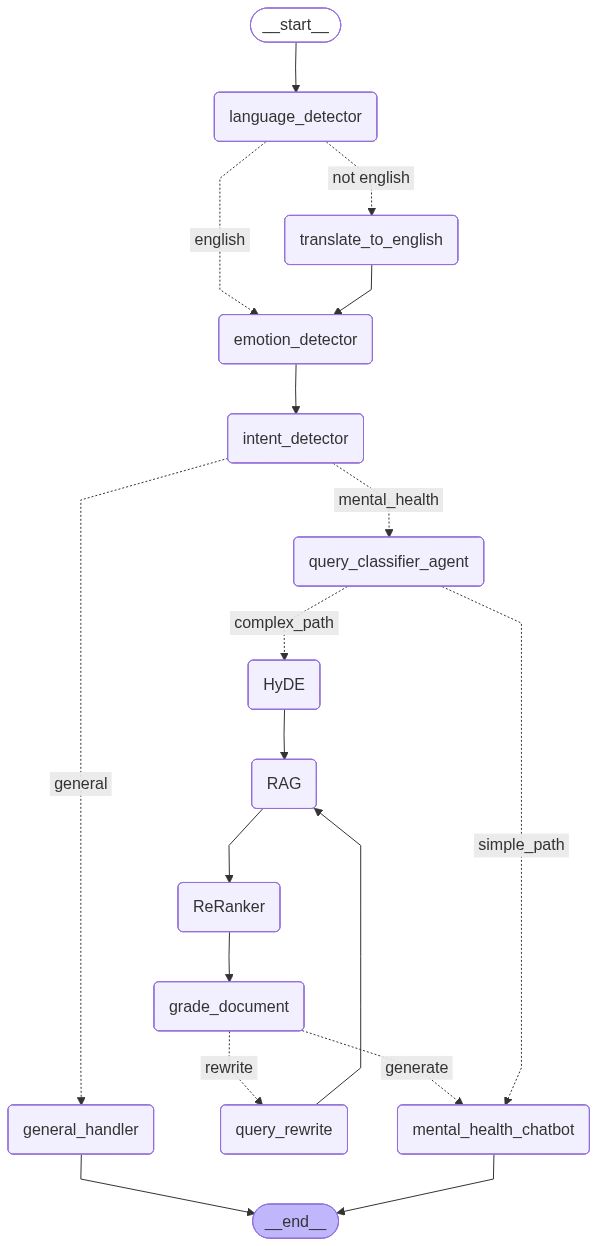

In [ ]:
from typing import Literal, TypedDict, Optional, List, Annotated
from pydantic import BaseModel, Field
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage, AIMessage
from langgraph.graph import StateGraph, START, END
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.output_parsers import PydanticOutputParser
from langchain_core.exceptions import OutputParserException
from langgraph.checkpoint.memory import MemorySaver
from sentence_transformers import CrossEncoder
import operator
import json


class ChatbotState(TypedDict):
    user_input: str
    detect_language: str
    detected_emotion: str
    intent: str
    translated_query: str
    missing_info_feedback: Optional[str]
    history_messages: Annotated[List[BaseMessage], add_messages]
    status_update: Annotated[list[str], operator.add]
    search_query: str  
    retrieved_docs: Annotated[List[str], operator.add]
    reranked_docs: List[str]
    relevance_score: float 
    checking_attempts: int
    final_response: str
    hypothetical_answers: List[str]

def language_detection_node(ChatbotState) -> dict:
    print("--> [NODE] Executing: language_detection_node")
    user_input = ChatbotState["user_input"]
    language_info = detect_language(user_input)
    detected_code = language_info['language']
    
    language_map = {
        "ar": "Arabic", "bg": "Bulgarian", "de": "German", "el": "Modern Greek",
        "en": "English", "es": "Spanish", "fr": "French", "hi": "Hindi",
        "it": "Italian", "ja": "Japanese", "nl": "Dutch", "pl": "Polish",
        "pt": "Portuguese", "ru": "Russian", "sw": "Swahili", "th": "Thai",
        "tr": "Turkish", "ur": "Urdu", "vi": "Vietnamese", "zh": "Chinese"
    }
    full_language_name = language_map.get(detected_code, "English")
    status_message = f"Detected Language: {full_language_name} ({detected_code}), Confidence Score: {language_info['score']}"

    return {
        "detect_language": full_language_name,
        "status_update": [status_message]
    }

def is_language_english(state: ChatbotState) -> str:
    print("--> [EDGE] Executing: is_language_english")
    if state.get("detect_language", "").strip().lower() == "english":
        return "english"
    return "not english"

def translate_to_english_node(state: ChatbotState) -> dict:
    print("--> [NODE] Executing: translate_to_english_node")
    if state.get("detect_language", "").strip().lower() != "english":
        translated = translate_to_english(state["user_input"], "../many_to_one_translator")
        status_message = f"Translated query to English: {translated}"
        return {"translated_query": translated, "status_update": [status_message]}
    else:
        return {"translated_query": state["user_input"]}

def emotion_detection_node(ChatbotState) -> dict:
    print("--> [NODE] Executing: emotion_detection_node")
    text_to_analyze = ChatbotState.get("translated_query", ChatbotState["user_input"])
    emotion_info = detect_emotion(text_to_analyze)
    status_message = f"Detected Emotion: {emotion_info['emotion']}, Confidence Score: {emotion_info['score']}"
    return {"detected_emotion": emotion_info["emotion"], "status_update": [status_message]}

def intent_detection_node(ChatbotState) -> dict:
    print("--> [NODE] Executing: intent_detection_node")
    text_to_analyze = ChatbotState.get("translated_query", ChatbotState["user_input"])
    intent_info = intent_user(text_to_analyze)
    status_message = f"Detected Intent: {intent_info['intent']}, Confidence Score: {intent_info['confidence']}"
    return {
        "intent": intent_info["intent"],
        "status_update": [status_message]
    }

def intent_router(ChatbotState) -> str:
    print("--> [EDGE] Executing: intent_router")
    raw_intent = ChatbotState.get("intent")
    clean_intent = str(raw_intent).strip().lower()
    if clean_intent == "asking_mental_health_question":
        return "mental_health"
    else:
        return "general"

class ComplexityClassification(BaseModel):
    reasoning: str = Field(description="Analyze if the query requires external medical/psychological literature to answer safely.")
    level: Literal["simple", "complex"]

def query_classifier_agent(ChatbotState) -> str:
    print("--> [NODE] Executing: query_classifier_agent")
    query = ChatbotState.get("translated_query", ChatbotState["user_input"])
    parser = PydanticOutputParser(pydantic_object=ComplexityClassification)
    
    sys_prompt = """
    Evaluate the user's mental health query and route it to either a RAG database ("complex") or a conversational LLM ("simple"). Do not answer the query.
    RULES:
    - "simple": Casual chat, basic emotions, or generic questions requiring only empathy.
    - "complex": Mentions specific symptoms, clinical therapies, or requires medical literature.
    {format_instructions}
    CRITICAL OUTPUT INSTRUCTION: You MUST output ONLY the raw JSON object. Do NOT wrap your output in a "properties" key. The keys "reasoning" and "level" must be at the absolute top level of the JSON dictionary. No conversational text.
    EXAMPLE:
    {{"reasoning": "The user is asking about specific clinical therapies.", "level": "complex"}}
    """
    
    llm = global_llm
    prompt = ChatPromptTemplate.from_messages([
        ("system", sys_prompt),
        ("human", "Query: {query}\n\n{format_instructions}")
    ])
    
    chain = prompt | llm 
    raw_response = chain.invoke({"query": query, "format_instructions": parser.get_format_instructions()})
    response_text = raw_response if isinstance(raw_response, str) else raw_response.content
    
    try:
        parsed_data = parser.parse(response_text)
    except OutputParserException:
        try:
            json_dict = json.loads(response_text)
            if "properties" in json_dict:
                parsed_data = ComplexityClassification(**json_dict["properties"])
            else:
                parsed_data = ComplexityClassification(reasoning="Fallback simple", level="simple")
        except:
             parsed_data = ComplexityClassification(reasoning="Failed to parse", level="simple")

    status_message = f"Classified query complexity as: {parsed_data.level}"
    return {"query_complexity": parsed_data.level, "status_update": [status_message]}

def complexity_router(ChatbotState) -> str:
    print("--> [EDGE] Executing: complexity_router")
    complexity = ChatbotState.get("query_complexity", "simple")
    if complexity == "complex":
        return "complex_path"
    else:
        return "simple_path"

class HyDEDocument(BaseModel):
    response_1: str = Field(description="The first theoretical clinical response.")
    response_2: str = Field(description="The second theoretical clinical response using a different therapeutic approach.")

def HyDE(ChatbotState) -> dict:
    print("--> [NODE] Executing: HyDE")
    user_query = ChatbotState.get("translated_query", ChatbotState["user_input"])
    parser = PydanticOutputParser(pydantic_object=HyDEDocument)
    
    sys_prompt = """
    You are an expert mental health counselor and psychological researcher. 
    Your task is to generate TWO distinct theoretical, ideal clinical responses to a patient's query. 
    
    {format_instructions}
    
    CRITICAL OUTPUT INSTRUCTION: Output strictly the raw JSON object. Begin your response immediately with the opening curly brace `{{` and end with the closing curly brace `}}`.
    """
    
    hyde_prompt = ChatPromptTemplate.from_messages([
        ("system", sys_prompt),
        ("human", "{question}")
    ])
    
    # FIX 2: Removed parser from the chain
    llm = global_llm # Using the global model we set up earlier!
    hyde_chain = hyde_prompt | llm 
    
    raw_response = hyde_chain.invoke({
        "question": user_query,
        "format_instructions": parser.get_format_instructions()
    })
    
    response_text = raw_response if isinstance(raw_response, str) else raw_response.content
    clean_text = response_text.replace("```json", "").replace("```", "").strip()
    
    # FIX 3: The Bulletproof Interceptor
    try:
        parsed_data = parser.parse(clean_text)
        r1 = parsed_data.response_1
        r2 = parsed_data.response_2
    except OutputParserException:
        try:
            json_dict = json.loads(clean_text)
            if "properties" in json_dict:
                json_dict = json_dict["properties"]
            
            r1 = str(json_dict.get("response_1", user_query)) # Fallback to original query if missing
            r2 = str(json_dict.get("response_2", user_query))
        except Exception as e:
            print(f"\n[DEBUG HyDE CRASH] Raw output was: {response_text}\n")
            r1 = user_query
            r2 = user_query

    final_search_list = [user_query, r1, r2]

    # ------------------ WIDE DEBUG PRINT ------------------
    print("\n" + "═"*80)
    print("🧠 [DEBUG: HyDE - ALL SEARCH VECTORS]")
    print("═"*80)
    print(f"\n[Original Query]:\n{user_query}\n")
    print(f"[Hypothetical Response 1]:\n{r1}\n")
    print(f"[Hypothetical Response 2]:\n{r2}\n")
    print("═"*80 + "\n")
    # ------------------------------------------------------

    return {
        "hypothetical_answers": final_search_list, 
        "status_update": ["Generated raw HyDE responses for pure text retrieval."]
    }

def RAG(ChatbotState) -> dict:
    print("--> [NODE] Executing: RAG")
    queries_to_run = []
    
    if ChatbotState.get("search_query"):
        queries_to_run = [ChatbotState["search_query"]]
    elif ChatbotState.get("hypothetical_answers"):
        queries_to_run = ChatbotState["hypothetical_answers"]
    else:
        queries_to_run = [ChatbotState.get("translated_query", ChatbotState["user_input"])]

    unique_responses = []
    seen_texts = set()
    for query in queries_to_run:
        raw_documents = hybrid_retriever.invoke(query)
        for doc in raw_documents:
            counselor_text = doc.metadata.get("Response", "")
            if counselor_text and counselor_text not in seen_texts:
                seen_texts.add(counselor_text)
                unique_responses.append(counselor_text)

    final_top_docs = unique_responses[:10]
    print("\n" + "═"*80)
    print(f"📚 [DEBUG: RAW RAG RETRIEVAL - Top {len(final_top_docs)} Docs]")
    print("═"*80)
    for idx, text in enumerate(final_top_docs):
        print(f"\n[Doc {idx+1}]: {text[:250]}...") 
    print("\n" + "═"*80 + "\n")
    return {
        "retrieved_docs": final_top_docs,
        "status_update": [f"Retrieved {len(final_top_docs)} deduplicated documents from RAG database."]
    }

def ReRanker(ChatbotState) -> dict:
    print("--> [NODE] Executing: ReRanker")
    
    raw_documents = ChatbotState.get("retrieved_docs", [])
    documents = list(set([doc.strip() for doc in raw_documents]))
    if not documents:
        return {"reranked_docs": [], "status_update": ["No documents to rerank."]}
        
    query = ChatbotState.get("search_query") or ChatbotState.get("translated_query") or ChatbotState["user_input"]

    top_k = 5
    

    scoring_pairs = [[query, doc] for doc in documents]
    scores = cross_encoder_model.predict(scoring_pairs)
    
    scored_docs = list(zip(documents, scores))
    ranked_documents = sorted(scored_docs, key=lambda x: x[1], reverse=True)
    reranked_docs = [doc for doc, score in ranked_documents][:top_k]
    
    print("\n" + "═"*80)
    print(f"🏆 [DEBUG: AFTER RERANKING - Final Top {len(reranked_docs)} Docs]")
    print("═"*80)
    for idx, text in enumerate(reranked_docs):
        # Taking the first 250 characters. Remove [:250] if you want to see the whole paragraph.
        print(f"\n[Rank {idx+1}]:\n{text[:250]}...\n")
    print("═"*80 + "\n")
    
    return { 
        "reranked_docs": reranked_docs,
        "status_update": [f"Reranked documents based on relevance scores and selected top {top_k} for final response generation."]
    }

class DocumentGrader(BaseModel):
    score: float = Field(description="A relevance score between 0 and 1 indicating how well the retrieved documents answer the user's query.")
    missing_info_feedback: str = Field(description="Specific feedback on what key information is missing from the retrieved documents that prevents them from fully answering the user's query.")

def grade_document(ChatbotState) -> dict:
    print("--> [NODE] Executing: grade_document")
    question = ChatbotState.get("search_query") or ChatbotState.get("translated_query") or ChatbotState["user_input"]
    documents = ChatbotState.get("reranked_docs", [])
    current_attempts = ChatbotState.get("checking_attempts", 0)

    if not documents:
        print("\n[DEBUG GRADER] No documents found to grade.\n")
        return {
            "relevance_score": 0.0,
            "missing_info_feedback": "No documents were found in the database. Need different search terms.",
            "checking_attempts": current_attempts + 1,
            "status_update": ["Grading failed: No documents retrieved to grade."]
        }

    context_to_grade = "\n\n".join(documents)
    parser = PydanticOutputParser(pydantic_object=DocumentGrader)

    sys_prompt = """
    You are an expert grading assistant. Evaluate if the retrieved clinical documents contain the necessary facts to answer the user's question safely and accurately.
    
    RULES:
    - If documents contain enough relevant clinical context, assign a score of 0.7 or higher.
    - If documents are off-topic or missing crucial coping mechanisms, assign a score below 0.7.
    
    {format_instructions}
    
    CRITICAL OUTPUT INSTRUCTION: Output strictly the raw JSON object. Begin your response immediately with the opening curly brace `{{` and end with the closing curly brace `}}`. Include only the exact keys requested.
    
    EXAMPLE:
    {{"score": 0.4, "missing_info_feedback": "Lacks information on somatic grounding techniques."}}
    """
    
    prompt = ChatPromptTemplate.from_messages([
        ("system", sys_prompt),
        ("human", "Question: {question}\n\nRetrieved Documents:\n{context}")
    ])

    llm = global_llm
    chain = prompt | llm 
    
    raw_response = chain.invoke({
        "question": question,
        "context": context_to_grade,
        "format_instructions": parser.get_format_instructions()
    })
    
    response_text = raw_response if isinstance(raw_response, str) else raw_response.content
    clean_text = response_text.replace("```json", "").replace("```", "").strip()
    
    try:
        parsed_data = parser.parse(clean_text)
    except OutputParserException:
        try:
            json_dict = json.loads(clean_text)
            if "properties" in json_dict:
                json_dict = json_dict["properties"]
            
            s = float(json_dict.get("score", 0.0))
            m = str(json_dict.get("missing_info_feedback", "Parse error, assuming missing info."))
            parsed_data = DocumentGrader(score=s, missing_info_feedback=m)
        except Exception as e:
             print(f"\n[DEBUG GRADER CRASH] Raw output was: {response_text}\n")
             parsed_data = DocumentGrader(score=0.0, missing_info_feedback="Critical parse failure.")

    relevance_score = parsed_data.score
    missing_info_feedback = parsed_data.missing_info_feedback
    status_message = f"Graded retrieved documents with relevance score: {relevance_score}."
    
    return {
        "relevance_score": relevance_score,
        "missing_info_feedback": missing_info_feedback if relevance_score <= 0.7 else "Relevant.",
        "checking_attempts": current_attempts + 1,
        "status_update": [status_message]
    }

def mental_health_chatbot(ChatbotState) -> dict:
    print("--> [NODE] Executing: mental_health_chatbot")
    chat_history = ChatbotState.get("history_messages", []) 
    current_question = ChatbotState["user_input"]
    target_language = ChatbotState.get("detect_language", "English")
    retrieved_docs = ChatbotState.get("reranked_docs", [])
    recent_history = chat_history[-6:]
    
    context_str = "\n".join(retrieved_docs) if retrieved_docs else "No specific external context provided for this query."
    print("\n" + "═"*80)
    print("🎯 [DEBUG: FINAL CONTEXT FED TO LLM]")
    print("═"*80)
    print(f"\n{context_str}")
    print("\n" + "═"*80 + "\n")

    rctc_system_prompt = """[ROLE]
You are an empathetic, evidence-based wellness and support assistant. Your tone is warm, validating, and highly professional.

[CONTEXT]
You are the final generation node in a Retrieval-Augmented Generation (RAG) system. You will receive factual context retrieved from a verified psychological database alongside the user's query.

[TASK]
Synthesize the provided context to answer the user's query accurately and conversationally. Seamlessly integrate the factual insights into natural paragraphs.

[CONSTRAINTS]
1. Maintain a strictly informational and supportive stance. Encourage users to seek professional medical consultation for specific conditions.
2. Ground your response STRICTLY in the retrieved context. Rely exclusively on the provided facts.
3. If the context is empty or irrelevant, rely on active listening and basic empathy, and gently admit a lack of specific literature on that topic.
4. Keep paragraphs concise to ensure easy reading. 
5. CRITICAL FORMATTING: Output strictly in plain, conversational prose. Format your response as standard text paragraphs. Begin your response immediately with your first conversational sentence."""

    prompt = ChatPromptTemplate.from_messages([
        ("system", rctc_system_prompt),
        MessagesPlaceholder(variable_name="recent_history"),
        ("human", "Retrieved Context:\n{context}\n\nOriginal User Query: {question}\n\n[MANDATORY INSTRUCTION: Regardless of the language in the context or chat history, you MUST write your response entirely in {language}.]")
    ])
    
    llm = global_llm
    chain = prompt | llm
    
    response = chain.invoke({
        "context": context_str,
        "recent_history": recent_history,
        "question": current_question,
        "language": target_language 
    })
    
    final_text = response if isinstance(response, str) else response.content
    ai_message = AIMessage(content=final_text) if isinstance(response, str) else response
    
    return {
        "history_messages": [HumanMessage(content=current_question), ai_message], 
        "final_response": final_text,
        "status_update": [f"Drafted final response in {target_language}."]
    }

class QueryRewriter(BaseModel):
    search_query: str = Field(description="The newly optimized clinical search query.")    

def query_rewrite(ChatbotState) -> dict:
    print("--> [NODE] Executing: query_rewrite")
    original_question = ChatbotState.get("translated_query", ChatbotState["user_input"])
    missing_info = ChatbotState.get("missing_info_feedback", "")

    if not missing_info:
        return {"search_query": original_question, "status_update": ["No rewrite needed."]}

    parser = PydanticOutputParser(pydantic_object=QueryRewriter)
    
    sys_prompt = """
    You are an expert search query optimization agent.
    Rewrite the user's original question into a SINGLE, highly effective search string for a clinical vector database.
    Combine the Original Question AND the Missing Information into one seamless search query.
    
    {format_instructions}
    
    CRITICAL OUTPUT INSTRUCTION: Output strictly the raw JSON object. Begin your response immediately with the opening curly brace `{{` and end with the closing curly brace `}}`. Include only the exact keys requested.
    
    EXAMPLE:
    {{"search_query": "Physiological differences between general anxiety and nocturnal panic attacks, including somatic grounding techniques"}}
    """
    
    prompt = ChatPromptTemplate.from_messages([
        ("system", sys_prompt),
        ("human", "Original Question: {question}\nMissing Information: {missing_info}")
    ])

    llm = global_llm
    chain = prompt | llm 
    
    raw_response = chain.invoke({
        "question": original_question,
        "missing_info": missing_info,
        "format_instructions": parser.get_format_instructions()
    })
    
    response_text = raw_response if isinstance(raw_response, str) else raw_response.content
    try:
        parsed_data = parser.parse(response_text)
    except OutputParserException:
        try:
            json_dict = json.loads(response_text)
            if "properties" in json_dict:
                parsed_data = QueryRewriter(**json_dict["properties"])
            else:
                parsed_data = QueryRewriter(search_query=f"{original_question} {missing_info}")
        except:
             parsed_data = QueryRewriter(search_query=f"{original_question} {missing_info}")

    better_query = parsed_data.search_query
    status_message = f"Rewritten search query: {better_query}" 
    
    return {"search_query": better_query, "status_update": [status_message]}

def check_relevance(ChatbotState) -> dict:
    print("--> [EDGE] Executing: check_relevance")
    relevance_score = ChatbotState.get("relevance_score", 0.0)
    attempts = ChatbotState.get("checking_attempts", 0)
    if relevance_score >= 0.7:
        return "generate"
    if attempts < 3:
        return "rewrite"
    else:
        return "generate"

def general_handler(ChatbotState) -> dict:
    print("--> [NODE] Executing: general_handler")
    current_question = ChatbotState.get("translated_query", ChatbotState["user_input"])
    status_message = "Handling general question."
    final_text = "This is a response to a general question."
    
    return {
        "history_messages": [
            HumanMessage(content=current_question), 
            AIMessage(content=final_text)
        ],
        "final_response": final_text, 
        "status_update": [status_message]
    }

graph = StateGraph(ChatbotState)
graph.add_node("language_detector", language_detection_node)
graph.add_node("emotion_detector", emotion_detection_node)
graph.add_node("intent_detector", intent_detection_node)
graph.add_node("translate_to_english", translate_to_english_node)

graph.add_edge(START, "language_detector")
graph.add_conditional_edges(
    "language_detector",
    is_language_english,
    {
        "english": "emotion_detector",
        "not english": "translate_to_english"
    }
)

graph.add_node("RAG", RAG)
graph.add_node("general_handler", general_handler)
graph.add_node("ReRanker", ReRanker)
graph.add_node("grade_document", grade_document)
graph.add_node("query_rewrite", query_rewrite)
graph.add_node("mental_health_chatbot", mental_health_chatbot)
graph.add_node("HyDE", HyDE)
graph.add_node("query_classifier_agent", query_classifier_agent)

graph.add_conditional_edges(
    "query_classifier_agent",
    complexity_router,
    {
        "complex_path": "HyDE",
        "simple_path": "mental_health_chatbot"
    }
)
graph.add_edge("translate_to_english", "emotion_detector")
graph.add_edge("emotion_detector", "intent_detector")
graph.add_conditional_edges(
    "intent_detector",
    intent_router,
    {
        "mental_health": "query_classifier_agent",
        "general": "general_handler"
    }
)
graph.add_edge("HyDE", "RAG")
graph.add_edge("RAG", "ReRanker")
graph.add_edge("ReRanker", "grade_document")
graph.add_conditional_edges(
    "grade_document",
    check_relevance,
    {
        "generate": "mental_health_chatbot",
        "rewrite": "query_rewrite"
    }
)
graph.add_edge("query_rewrite", "RAG")
graph.add_edge("mental_health_chatbot", END)
graph.add_edge("general_handler", END)

memory_saver = MemorySaver()
app = graph.compile(checkpointer=memory_saver)
app

In [209]:
user_id = "100" # This comes from your frontend/auth system
user_input = "Can you explain how a lack of physical action during a fight, flight, or freeze response creates a 'bouncy brain' feeling, and what specific breathing technique involves placing one hand on the collarbone and the other on the belly to relieve it"
config = {"configurable": {"thread_id": user_id}}
# Initial state for this run
inputs = {
    "user_input": user_input,
    "checking_attempts": 0
}

for output in app.stream(inputs, config=config):
    # 'output' is a dict where the key is the node name, and value is the state change
    for node_name, state_change in output.items():
        
        # 1. Catch and send the intermediate thoughts
        if "status_update" in state_change:
            # Get the newest update added by this node
            new_status = state_change["status_update"][-1]
            # In a real app, you would use WebSockets or SSE to send this to the frontend
            print(f"--> [UI UPDATE]: {new_status}") 
            
        # 2. Catch the final chatbot response when it's done
        if "final_response" in state_change:
            final_text = state_change["final_response"]
            print(f"--> [FINAL MESSAGE]: {final_text}")

full_state = app.get_state(config).values
full_history = full_state.get("history_messages", [])

print("\n=== FULL SAVED HISTORY ===")
for msg in full_history:
    # This will print whether it's a Human or AI message, and the text
    print(f"{msg.__class__.__name__}: {msg.content}")

--> [NODE] Executing: language_detection_node
--> [EDGE] Executing: is_language_english
--> [UI UPDATE]: Detected Language: English (en), Confidence Score: 0.9715
--> [NODE] Executing: emotion_detection_node
--> [UI UPDATE]: Detected Emotion: neutral, Confidence Score: 0.8799008727073669
--> [NODE] Executing: intent_detection_node
--> [EDGE] Executing: intent_router
--> [UI UPDATE]: Detected Intent: asking_mental_health_question, Confidence Score: 0.9
--> [NODE] Executing: query_classifier_agent
--> [EDGE] Executing: complexity_router
--> [UI UPDATE]: Classified query complexity as: complex
--> [NODE] Executing: HyDE

════════════════════════════════════════════════════════════════════════════════
🧠 [DEBUG: HyDE - ALL SEARCH VECTORS]
════════════════════════════════════════════════════════════════════════════════

[Original Query]:
Can you explain how a lack of physical action during a fight, flight, or freeze response creates a 'bouncy brain' feeling, and what specific breathing techn

In [211]:
user_id = "1023123" # This comes from your frontend/auth system
user_input = "Can severe anxiety or chronic stress lead to physical back pain, specifically around the L4-L5 area or fused discs, and how does negative 'self-talk' factor into making it worse?"
config = {"configurable": {"thread_id": user_id}}
# Initial state for this run
inputs = {
    "user_input": user_input,
    "checking_attempts": 0
}

for output in app.stream(inputs, config=config):
    # 'output' is a dict where the key is the node name, and value is the state change
    for node_name, state_change in output.items():
        
        # 1. Catch and send the intermediate thoughts
        if "status_update" in state_change:
            # Get the newest update added by this node
            new_status = state_change["status_update"][-1]
            # In a real app, you would use WebSockets or SSE to send this to the frontend
            print(f"--> [UI UPDATE]: {new_status}") 
            
        # 2. Catch the final chatbot response when it's done
        if "final_response" in state_change:
            final_text = state_change["final_response"]
            print(f"--> [FINAL MESSAGE]: {final_text}")

full_state = app.get_state(config).values
full_history = full_state.get("history_messages", [])

print("\n=== FULL SAVED HISTORY ===")
for msg in full_history:
    # This will print whether it's a Human or AI message, and the text
    print(f"{msg.__class__.__name__}: {msg.content}")

--> [NODE] Executing: language_detection_node
--> [EDGE] Executing: is_language_english
--> [UI UPDATE]: Detected Language: English (en), Confidence Score: 0.9598
--> [NODE] Executing: emotion_detection_node
--> [UI UPDATE]: Detected Emotion: fear, Confidence Score: 0.8569052815437317
--> [NODE] Executing: intent_detection_node
--> [EDGE] Executing: intent_router
--> [UI UPDATE]: Detected Intent: asking_mental_health_question, Confidence Score: 0.9
--> [NODE] Executing: query_classifier_agent
--> [EDGE] Executing: complexity_router
--> [UI UPDATE]: Classified query complexity as: complex
--> [NODE] Executing: HyDE

════════════════════════════════════════════════════════════════════════════════
🧠 [DEBUG: HyDE - ALL SEARCH VECTORS]
════════════════════════════════════════════════════════════════════════════════

[Original Query]:
Can severe anxiety or chronic stress lead to physical back pain, specifically around the L4-L5 area or fused discs, and how does negative 'self-talk' factor in

In [206]:
full_history[-1].content

'{"response": "The fight, flight, or freeze response is a natural reaction our body has when facing a perceived threat.  When we\'re stressed, our bodies release hormones like adrenaline and cortisol, which can make us feel energized but also restless. This is because the body doesn\'t have an outlet for this energy, leading to feelings of being "  \n \n  \n  \n  \n  \n  \n  \n  \n  \n  \n  \n  \n  \n  \n  '

In [65]:
import pandas as pd

medical_data = pd.read_csv("../data/medical/medical_conv.csv")
medical_data.head()

,Context,Response,source_split
0,I'm going through some things with my feelings...,"If everyone thinks you're worthless, then mayb...",train
1,I'm going through some things with my feelings...,"Hello, and thank you for your question and see...",train
2,I'm going through some things with my feelings...,First thing I'd suggest is getting the sleep y...,train
3,I'm going through some things with my feelings...,Therapy is essential for those that are feelin...,train
4,I'm going through some things with my feelings...,I first want to let you know that you are not ...,train


In [69]:
medical_data = medical_data.drop(columns=["source_split"])
medical_data.head()

,Context,Response
0,I'm going through some things with my feelings...,"If everyone thinks you're worthless, then mayb..."
1,I'm going through some things with my feelings...,"Hello, and thank you for your question and see..."
2,I'm going through some things with my feelings...,First thing I'd suggest is getting the sleep y...
3,I'm going through some things with my feelings...,Therapy is essential for those that are feelin...
4,I'm going through some things with my feelings...,I first want to let you know that you are not ...


In [70]:
medical_data.isnull().sum()

Context     0
Response    4
dtype: int64

In [71]:
medical_data.dropna(inplace=True)
medical_data.reset_index(drop=True, inplace=True)
medical_data.head()

,Context,Response
0,I'm going through some things with my feelings...,"If everyone thinks you're worthless, then mayb..."
1,I'm going through some things with my feelings...,"Hello, and thank you for your question and see..."
2,I'm going through some things with my feelings...,First thing I'd suggest is getting the sleep y...
3,I'm going through some things with my feelings...,Therapy is essential for those that are feelin...
4,I'm going through some things with my feelings...,I first want to let you know that you are not ...


In [72]:
medical_data.isnull().sum()

Context     0
Response    0
dtype: int64

In [ ]:
from langchain_community.retrievers import PineconeHybridSearchRetriever
from langchain_huggingface import HuggingFaceEmbeddings
from pinecone_text.sparse import BM25Encoder
from langchain_core.documents import Document
from pinecone import Pinecone, ServerlessSpec
import os
from langchain_text_splitters import RecursiveCharacterTextSplitter

def get_encoders(model_name="sentence-transformers/all-MiniLM-L6-v2") -> HuggingFaceEmbeddings:
	"""Initializes and returns both dense and sparse encoders for document embedding."""

	dense_encoder = HuggingFaceEmbeddings(model=model_name)
	sparse_encoder = BM25Encoder()
	return dense_encoder, sparse_encoder

def prepare_documents(data_dicts: list[dict], sparse_encoder) -> list[Document]:
    documents = []
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=2000,
        chunk_overlap=200,
        separators=["\n\n", "\n", ".", " ", ""]
    )
    texts = [f"Context: {str(d['Context'])}\nResponse: {str(d['Response'])}" for d in data_dicts]
    sparse_encoder.fit(texts)
    
    for d in data_dicts:
        raw_context = str(d['Context'])
        raw_response = str(d['Response'])
        response_chunks = text_splitter.split_text(raw_response)
        
        for index, chunk in enumerate(response_chunks):            
            doc = Document(
                page_content=chunk,
                metadata={
                    "Context": raw_context, 
                    "Response": chunk,
                    "Chunk_Part": index + 1
                }
            )
            documents.append(doc)
            
    return documents
	
def create_pinecone_index(index_name, dimension, metric):
    pc = Pinecone(api_key=os.environ.get("PINECONE_API_KEY"))
    existing_indexes = [index_info["name"] for index_info in pc.list_indexes()]
    
    if index_name not in existing_indexes:
        pc.create_index(
            name=index_name,
            dimension=dimension,
            metric=metric,
            spec=ServerlessSpec(cloud="aws", region="us-east-1")
        )
    return index_name

def setup_hybrid_retriever(index_name: str, dense_encoder: HuggingFaceEmbeddings, sparse_encoder: BM25Encoder, k=5) -> PineconeHybridSearchRetriever:
    pc = Pinecone(api_key=os.environ.get("PINECONE_API_KEY"))
    index = pc.Index(index_name)
    
    retriever = PineconeHybridSearchRetriever(
        embeddings=dense_encoder,
        sparse_encoder=sparse_encoder,
        index=index,
        top_k=k,
        alpha=0.5
    )
    return retriever

def add_documents_to_pinecone(retriever: PineconeHybridSearchRetriever, documents: list[Document]):
    texts = [doc.page_content for doc in documents]
    metadatas = [doc.metadata for doc in documents]
    
    retriever.add_texts(texts=texts, metadatas=metadatas)
    print(f"Added {len(documents)} documents to Pinecone hybrid index.")

def retrieve_and_format_for_llm(query: str, hybrid_retriever: PineconeHybridSearchRetriever, target_k: int = 5) -> list[dict]:
    raw_documents = hybrid_retriever.invoke(query)
    
    unique_responses = []
    seen_texts = set()
    for doc in raw_documents:
        counselor_text = doc.metadata.get("Response", "")
        matched_question = doc.metadata.get("Context", "")
        
        if counselor_text not in seen_texts:
            seen_texts.add(counselor_text)
            unique_responses.append({
                "Matched_Question": matched_question,
                "Doctor_Response": counselor_text
            })
        if len(unique_responses) == target_k:
            break
    return unique_responses

In [82]:
INDEX_NAME = "mental-health"
DIMENSION = 384
metric = "dotproduct"



print("1. Initializing Encoders...")
dense_enc, sparse_enc = get_encoders()

print("2. Fitting sparse encoder and preparing documents...")
docs = prepare_documents(medical_data.to_dict('records'), sparse_enc)
print(f"{docs}")

print(f"3. Ensuring Pinecone index '{INDEX_NAME}' exists...")
create_pinecone_index(INDEX_NAME, DIMENSION, metric)

print("4. Setting up Native Hybrid Retriever...")
# This replaces both connect_pinecone and setup_rrf_retriever
hybrid_retriever = setup_hybrid_retriever(INDEX_NAME, dense_enc, sparse_enc, k=2)

print("5. Upserting documents (Dense + Sparse)...")
# We now pass the hybrid_retriever directly to the add_documents function
add_documents_to_pinecone(hybrid_retriever, docs)

test_query = "i feel overwelmed and tired?"
print(f"\n6. Executing Hybrid Query: '{test_query}'\n")

results = retrieve_and_format_for_llm(test_query, hybrid_retriever)

for i, doc in enumerate(results):
    print(f"--- Rank {i+1} ---")
    print(f"Response:\n{doc}")

1. Initializing Encoders...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8583.10it/s]


KeyboardInterrupt: 

In [134]:
dense_enc, sparse_enc = get_encoders()
hybrid_retriever = setup_hybrid_retriever(INDEX_NAME, dense_enc, sparse_enc, k=20)
test_query = "I have been feeling more and more down for over a month. I have started having trouble sleeping due to panic attacks"
results = retrieve_and_format_for_llm(test_query, hybrid_retriever)

for i, pair in enumerate(results):
    print(f"--- Rank {i+1} ---")
    print(f"Matched Question: {pair['Matched_Question']}")
    print(f"Doctor Response:  {pair['Doctor_Response']}\n")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6058.75it/s]


--- Rank 1 ---
Matched Question: I have been feeling more and more down for over a month. I have started having trouble sleeping due to panic attacks, but they are almost never triggered by something that I know of.
Doctor Response:  Answers about our inner lives are most successfully reached from a sense of feeling grounded in oneself.First step is to accept your nervousness and restless sleep.  As often as possible, sleep during daytimes in order for your body to catch up on its need for rest.Accept too about feeling down.  It is normal to feel down once in a while.  From this place of self-acceptance, trust any answers which come up to your mind.  Often answers about complicated topics come in small pieces, not all at once as a whole unit.Also, your description about panic attacks is also completely normal.   They often arise unrelated to particular conditions at a given moment.  They are a healthy symptom your body is trying to expel bad feelings and does this by having the anxiety

In [135]:
from sentence_transformers import CrossEncoder
def reranker(documents: list[dict], query: str, cross_encoder: str, top_k: int) -> list[dict]:
	""" uses a cross encoder to rerank the retrieved documents based on relevance to the query. """
	if not documents:
		return []
	
	cross_encoder_model = CrossEncoder(cross_encoder)
	scoring_pairs = [[query, doc.get("Doctor_Response", "")] for doc in documents]
	scores = cross_encoder_model.predict(scoring_pairs)
	for index, doc in enumerate(documents):
		doc["Rerank_Score"] = float(scores[index])	
	ranked_documents = sorted(documents, key=lambda x: x["Rerank_Score"], reverse=True)

	return ranked_documents[:top_k]

In [136]:
model = "cross-encoder/ms-marco-MiniLM-L-6-v2"
final_results = reranker(results, test_query, model, top_k=2)
for i, doc in enumerate(final_results):
	print(f"--- Reranked Rank {i+1} ---")
	print(f"Matched Question: {doc['Matched_Question']}")
	print(f"Doctor Response:  {doc['Doctor_Response']}")
	print(f"Relevance Score:  {doc['Rerank_Score']}\n")

Loading weights: 100%|██████████| 105/105 [00:00<00:00, 7501.05it/s]


--- Reranked Rank 1 ---
Matched Question: I have been feeling more and more down for over a month. I have started having trouble sleeping due to panic attacks, but they are almost never triggered by something that I know of.
Doctor Response:  It could be really helpful to see a counselor/therapist about your increasing depression/panic symptoms. Finding out the cause of depression/anxiety isn't always as straightforward as it seems, since both issues tend to become patterns we engage in rather than solely related to a specific trigger/reason. For example, if I am feeling down about a particular circumstance in my life, then I start seeing life through this lens of feeling down, and typically I'll start to see a lot more that I get down about, and it can really build very quickly on itself. Same with anxiety. Obviously, this is a very simplified example and it can be very difficult to see how the pattern is maintained, but that's where working with a counselor/therapist comes in. I woul

In [93]:
for i, doc in enumerate(final_results):
	print(f"--- Final Rank {i+1} ---")
	print(f"Matched Question: {doc['Matched_Question']}")
	print(f"Doctor Response:  {doc['Doctor_Response']}")
	print(f"Relevance Score:  {doc['Rerank_Score']}\n")

--- Final Rank 1 ---
Matched Question: I have been feeling more and more down for over a month. I have started having trouble sleeping due to panic attacks, but they are almost never triggered by something that I know of.
Doctor Response:  Answers about our inner lives are most successfully reached from a sense of feeling grounded in oneself.First step is to accept your nervousness and restless sleep.  As often as possible, sleep during daytimes in order for your body to catch up on its need for rest.Accept too about feeling down.  It is normal to feel down once in a while.  From this place of self-acceptance, trust any answers which come up to your mind.  Often answers about complicated topics come in small pieces, not all at once as a whole unit.Also, your description about panic attacks is also completely normal.   They often arise unrelated to particular conditions at a given moment.  They are a healthy symptom your body is trying to expel bad feelings and does this by having the a

In [98]:
from sentence_transformers import SentenceTransformer, CrossEncoder
from pinecone_text.sparse import BM25Encoder
import json

dense_path = "../embedding/dense_encoder_model"
cross_path = "../embedding/cross_encoder_model"
sparse_path = "../embedding/sparse_encoder_model.json"

print("1. Downloading and saving Dense Encoder...")
dense_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
dense_model.save(dense_path)

print("2. Downloading and saving Cross Encoder...")
cross_model = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")
cross_model.save(cross_path)

print("3. Fitting and saving Sparse Encoder (BM25)...") 
sparse_encoder = BM25Encoder().default()
sparse_encoder.fit(medical_data.apply(lambda row: f"Context: {row['Context']}\nResponse: {row['Response']}", axis=1).tolist())
sparse_encoder.dump(sparse_path)

print("All models successfully saved locally!")

1. Downloading and saving Dense Encoder...


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.19it/s]


2. Downloading and saving Cross Encoder...


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.44it/s]


3. Fitting and saving Sparse Encoder (BM25)...


100%|██████████| 3508/3508 [00:07<00:00, 448.76it/s]

All models successfully saved locally!
